## Imports

In [1]:
%%capture
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier

In [2]:
# Load java
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null

# check java and version
!which java
!java -version
!readlink -f $(which java)
!ls -la /usr/lib/jvm
!java --version
!javac --version


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

In [3]:

import itertools
import json
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyterrier as pt
from pathlib import Path


## Load dataset

In [4]:
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/project_handout'

docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
train_queries = pd.read_csv(f'{base}/train_queries.csv')
train_qrels   = pd.read_csv(f'{base}/train_qrels.csv')

## Verify dataset

In [5]:
print(docs.shape)
docs.sample(5, random_state=42)

(151993, 2)


,docno,text
114980,D114980,Italian Renaissance The Italian Renaissance (I...
88715,D88715,2018–19 NCAA Division I men's basketball seaso...
38065,D38065,Mount St. Helens Mount St. Helens or Louwala-C...
16042,D16042,Bachelor in Paradise (season 5) The fifth seas...
49231,D49231,I Could Use a Love Song The music video of the...


In [6]:
print(train_queries.shape)
train_queries.sample(5)

(10000, 2)


,qid,text
1368,1368,who is dawn married to in real housewives of c...
280,280,what's a dell from farmer in the dell
3898,3898,what is pepper's real name from iron man
9515,9515,who played lead guitar on thin lizzy whiskey i...
2105,2105,when did humans begin to live in san francisco


In [7]:
print(train_qrels.shape)
train_qrels.sample(5)

(17746, 4)


,qid,docno,relevance,iteration
7301,6668,D61452,2,0
14985,6403,D128179,2,0
4522,3270,D38350,1,0
5682,3648,D48224,1,0
7035,9727,D59270,2,0


In [8]:
print('Unique labels: \n', train_qrels['relevance'].unique())
print('\n')
print('Distribution of labels: \n', train_qrels[['qid','relevance']].groupby(by='relevance').count().reset_index())

Unique labels: 
 [2 1]


Distribution of labels: 
    relevance    qid
0          1   7746
1          2  10000


In [9]:
print(train_qrels[train_qrels['relevance'] == 2])

        qid    docno  relevance  iteration
0      5743       D2          2          0
1      6266      D13          2          0
2      7918      D17          2          0
6      5246      D73          2          0
8      9909      D83          2          0
...     ...      ...        ...        ...
17738  1703  D151968          2          0
17740  6956  D151976          2          0
17742  7811  D151981          2          0
17743  8331  D151982          2          0
17745  6556  D151991          2          0

[10000 rows x 4 columns]


In [10]:
qid = 8030

# Sneak peak into the query for qid D127677
qrels_for_qid = train_qrels[train_qrels['qid'] == qid]
print(qrels_for_qid)

# Sneak peak into document highly relevant for qid D127677
print('\nQuery')
print(train_queries.loc[train_queries['qid'] == qid, 'text'].iloc[0])

# Sneak peak into document somwwhat relevant for qid D127677
docno = qrels_for_qid.sort_values('relevance', ascending=False)['docno'].iloc[0]

print(f'\nRelevant document for qid {qid}: {docno}')
print(docs.loc[docs["docno"] == docno, "text"].iloc[0])

        qid    docno  relevance  iteration
15853  8030  D135228          2          0

Query
what was the first hotel casino in las vegas

Relevant document for qid 8030: D135228
Las Vegas Strip The first casino to be built on Highway 91 was the Pair-o-Dice Club in 1931, but the first resort on what is currently the Strip was the El Rancho Vegas, opening on April 3, 1941, with 63 rooms. That casino/ resort stood for almost 20 years before being destroyed by a fire in 1960. Its success spawned a second hotel on what would become the Strip, the Hotel Last Frontier, in 1942. Organized crime figures such as New York's Bugsy Siegel took interest in the growing gaming center leading to other resorts such as the Flamingo, which opened in 1946, and the Desert Inn, which opened in 1950. The funding for many projects was provided through the American National Insurance Company, which was based in the then notorious gambling empire of Galveston, Texas.[9][10]


# 2.1 Dataset

In [11]:
doc_lengths = docs["text"].str.split().str.len()
query_lengths = train_queries["text"].str.split().str.len()

res = pd.DataFrame({
    "total": [len(query_lengths), len(doc_lengths)],
    "min": [query_lengths.min(), doc_lengths.min()],
    "max": [query_lengths.max(), doc_lengths.max()],
    "median": [query_lengths.median(), doc_lengths.median()],
    "average": [query_lengths.mean(), doc_lengths.mean()]
}, index=["queries", "documents"])

res

,total,min,max,median,average
queries,10000,5,23,9.0,9.080600
documents,151993,1,2219,82.0,91.458784


### 2.1: Plot statistics

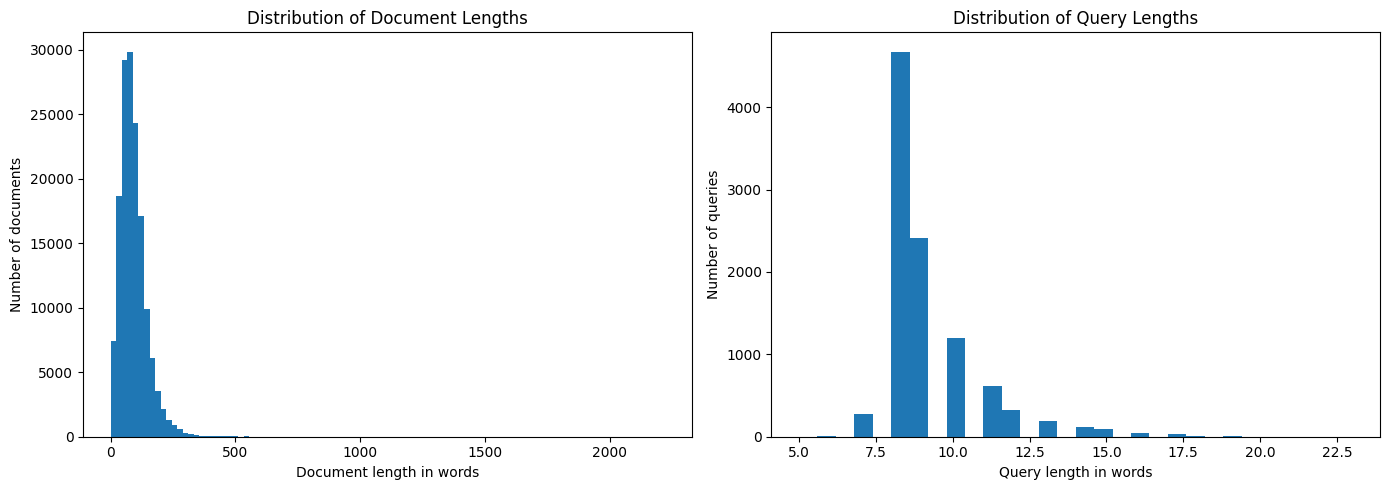

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Document length distribution
axes[0].hist(doc_lengths, bins=100)
axes[0].set_title("Distribution of Document Lengths")
axes[0].set_xlabel("Document length in words")
axes[0].set_ylabel("Number of documents")

# Query length distribution
axes[1].hist(query_lengths, bins=30)
axes[1].set_title("Distribution of Query Lengths")
axes[1].set_xlabel("Query length in words")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()

## PyTerrier

In [13]:
!find /usr/lib/jvm -name "libjvm.so" 2>/dev/null

/usr/lib/jvm/java-17-openjdk-amd64/lib/server/libjvm.so


### PyTerrier local

In [18]:
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# os.environ["JVM_PATH"] = "/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so"
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# import pyterrier as pt

# if not pt.java.started():
#     pt.java.init()

# print("JAVA_HOME:", os.environ["JAVA_HOME"])
# print("JVM_PATH:", os.environ["JVM_PATH"])
# print("Java started:", pt.java.started())

In [14]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

if not pt.started():
    pt.init()

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("Java started:", pt.java.started())

/tmp/ipykernel_9074/631900236.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Java started: True


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_9074/631900236.py:5: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


# 2.2 Build Indexes

In [15]:
index_path_default = "./indexes/default"
index_path_default_obj = Path(index_path_default)

if (index_path_default_obj / "data.properties").exists():
    print(f"Default index already exists at {index_path_default}. Loading without rebuilding.")

    index_ref = index_path_default
    index = pt.IndexFactory.of(index_ref)

else:
    print(f"Default index does not exist at {index_path_default}. Building index.")

    indexer = pt.IterDictIndexer(index_path_default, overwrite=True)
    index_ref = indexer.index(docs.to_dict(orient="records"))
    index = pt.IndexFactory.of(index_ref)

    print(f"Built default index at {index_path_default}")

print("Default index statistics:")
print(index.getCollectionStatistics().toString())

Default index already exists at ./indexes/default. Loading without rebuilding.
Default index statistics:
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [16]:
# Where does 'agenda' appear?
pointer = index.getLexicon()["agenda"]
print("Pointer: ", pointer)
for posting in index.getInvertedIndex().getPostings(pointer):
    print(f"{posting.toString()} doclen={posting.getDocumentLength()}")

Pointer:  term1186 Nt=94 TF=107 maxTF=2147483647 @{0 1092621 5}
ID(39) TF(1) doclen=41
ID(991) TF(4) doclen=39
ID(2341) TF(3) doclen=41
ID(3059) TF(1) doclen=67
ID(4389) TF(1) doclen=110
ID(5787) TF(1) doclen=62
ID(9143) TF(1) doclen=69
ID(11489) TF(1) doclen=61
ID(14860) TF(1) doclen=62
ID(16233) TF(1) doclen=86
ID(19621) TF(3) doclen=41
ID(19897) TF(1) doclen=61
ID(20135) TF(1) doclen=68
ID(21068) TF(1) doclen=41
ID(21335) TF(1) doclen=42
ID(21422) TF(1) doclen=95
ID(23838) TF(1) doclen=50
ID(25534) TF(1) doclen=47
ID(25669) TF(1) doclen=89
ID(26140) TF(1) doclen=87
ID(27337) TF(1) doclen=55
ID(27369) TF(1) doclen=40
ID(30083) TF(1) doclen=89
ID(32478) TF(1) doclen=41
ID(34664) TF(1) doclen=47
ID(34703) TF(1) doclen=96
ID(34825) TF(1) doclen=41
ID(35719) TF(1) doclen=81
ID(36910) TF(1) doclen=81
ID(47190) TF(1) doclen=61
ID(52318) TF(1) doclen=47
ID(52849) TF(1) doclen=47
ID(54718) TF(1) doclen=54
ID(55024) TF(1) doclen=54
ID(55034) TF(1) doclen=45
ID(57200) TF(1) doclen=88
ID(57286)

### 2.2.1 Full index

In [17]:
index_path_none = "./indexes/full"
index_path_none_obj = Path(index_path_none)

build_time_path_none = index_path_none_obj / "build_time.json"

if index_path_none_obj.exists():
    print(f"Index already exists at {index_path_none}. Loading without rebuilding.")

    index_none = pt.IndexFactory.of(index_path_none)

    if build_time_path_none.exists():
        with open(build_time_path_none, "r") as f:
            build_time_index_none = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_none:.2f}s")
    else:
        build_time_index_none = None
        print("No preserved build time found.")

else:
    print(f"Index does not exist at {index_path_none}. Building index.")

    start_time_index_none = time.perf_counter()

    indexer_none = pt.IterDictIndexer(
        index_path_none,
        overwrite=True,
        stopwords=None,
        stemmer=None
    )

    index_ref_none = indexer_none.index(docs.to_dict(orient="records"))
    index_none = pt.IndexFactory.of(index_ref_none)

    end_time_index_none = time.perf_counter()
    build_time_index_none = end_time_index_none - start_time_index_none

    with open(build_time_path_none, "w") as f:
        json.dump(
            {
                "description": "Full index",
                "build_time_milliseconds": build_time_index_none
            },
            f,
            indent=4
        )

    print(f"Built index and saved build time: {build_time_index_none:.2f}s")

# Validate loaded/built index
stats_stop = index_none.getCollectionStatistics()

Index already exists at ./indexes/full. Loading without rebuilding.
Loaded preserved build time: 31.61s


### 2.2.2 Stopwords removed

In [18]:
index_path_stop = "./indexes/stopwords"
index_path_stop_obj = Path(index_path_stop)

build_time_path_stop = index_path_stop_obj / "build_time.json"

if (index_path_stop_obj / "data.properties").exists():
    print(f"Stopwords index already exists at {index_path_stop}. Loading without rebuilding.")

    index_stop = pt.IndexFactory.of(index_path_stop)

    if build_time_path_stop.exists():
        with open(build_time_path_stop, "r") as f:
            build_time_index_stop = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop:.2f}s")
    else:
        build_time_index_stop = None
        print("No preserved build time found.")

else:
    print(f"Stopwords index does not exist at {index_path_stop}. Building index.")

    start_time_index_stop = time.perf_counter()

    indexer_stop = pt.IterDictIndexer(
        index_path_stop,
        overwrite=True,
        stopwords="terrier",
        stemmer=None
    )

    index_ref_stop = indexer_stop.index(docs.to_dict(orient="records"))
    index_stop = pt.IndexFactory.of(index_ref_stop)

    end_time_index_stop = time.perf_counter()
    build_time_index_stop = end_time_index_stop - start_time_index_stop

    with open(build_time_path_stop, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, no stemming",
                "build_time_milliseconds": build_time_index_stop
            },
            f,
            indent=4
        )

    print(f"Built stopwords index and saved build time: {build_time_index_stop:.2f}s")

# Validate loaded/built index
stats_stop = index_stop.getCollectionStatistics()

Stopwords index already exists at ./indexes/stopwords. Loading without rebuilding.
Loaded preserved build time: 24.25s


### 2.2.3 Stemming

In [19]:
index_path_stem = "./indexes/stemming"
index_path_stem_obj = Path(index_path_stem)

build_time_path_stem = index_path_stem_obj / "build_time.json"

if (index_path_stem_obj / "data.properties").exists():
    print(f"Stemming index already exists at {index_path_stem}. Loading without rebuilding.")

    index_stem = pt.IndexFactory.of(index_path_stem)

    if build_time_path_stem.exists():
        with open(build_time_path_stem, "r") as f:
            build_time_index_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stem:.2f}s")
    else:
        build_time_index_stem = None
        print("No preserved build time found.")

else:
    print(f"Stemming index does not exist at {index_path_stem}. Building index.")

    start_time_index_stem = time.perf_counter()

    indexer_stem = pt.IterDictIndexer(
        index_path_stem,
        overwrite=True,
        stopwords=None,
        stemmer="porter"
    )

    index_ref_stem = indexer_stem.index(docs.to_dict(orient="records"))
    index_stem = pt.IndexFactory.of(index_ref_stem)

    end_time_index_stem = time.perf_counter()
    build_time_index_stem = end_time_index_stem - start_time_index_stem

    with open(build_time_path_stem, "w") as f:
        json.dump(
            {
                "description": "No stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stem
            },
            f,
            indent=4
        )

    print(f"Built stemming index and saved build time: {build_time_index_stem:.2f}s")

# Validate loaded/built index
stats_stem = index_stem.getCollectionStatistics()

Stemming index already exists at ./indexes/stemming. Loading without rebuilding.
Loaded preserved build time: 26.73s


### 2.2.4 Stopwords and Stemming

In [20]:
index_path_stop_stem = "./indexes/stop-stem"
index_path_stop_stem_obj = Path(index_path_stop_stem)

build_time_path_stop_stem = index_path_stop_stem_obj / "build_time.json"

if (index_path_stop_stem_obj / "data.properties").exists():
    print(f"Stopwords + stemming index already exists at {index_path_stop_stem}. Loading without rebuilding.")

    index_stop_stem = pt.IndexFactory.of(index_path_stop_stem)

    if build_time_path_stop_stem.exists():
        with open(build_time_path_stop_stem, "r") as f:
            build_time_index_stop_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop_stem:.2f}s")
    else:
        build_time_index_stop_stem = None
        print("No preserved build time found.")

else:
    print(f"Stopwords + stemming index does not exist at {index_path_stop_stem}. Building index.")

    start_time_index_stop_stem = time.perf_counter()

    indexer_stop_stem = pt.IterDictIndexer(
        index_path_stop_stem,
        overwrite=True,
        stopwords="terrier",
        stemmer="porter"
    )

    index_ref_stop_stem = indexer_stop_stem.index(docs.to_dict(orient="records"))
    index_stop_stem = pt.IndexFactory.of(index_ref_stop_stem)

    end_time_index_stop_stem = time.perf_counter()
    build_time_index_stop_stem = end_time_index_stop_stem - start_time_index_stop_stem

    with open(build_time_path_stop_stem, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stop_stem
            },
            f,
            indent=4
        )

    print(f"Built stopwords + stemming index and saved build time: {build_time_index_stop_stem:.2f}s")

# Validate loaded/built index
stats_stop_stem = index_stop_stem.getCollectionStatistics()

Stopwords + stemming index already exists at ./indexes/stop-stem. Loading without rebuilding.
Loaded preserved build time: 24.78s


In [14]:
index_none.getLexicon()["the"].toString()

'term14 Nt=145101 TF=1099981 maxTF=2147483647 @{0 13198780 5}'

## Index statistics

In [21]:
print("* Index: Full")
print(index_none.getCollectionStatistics().toString())


* Index: Full
Number of documents: 151993
Number of terms: 160176
Number of postings: 9518322
Number of fields: 0
Number of tokens: 14483146
Field names: []
Positions:   false



In [22]:
print("* Index: Stopwords removed")
print(index_stop.getCollectionStatistics().toString())

* Index: Stopwords removed
Number of documents: 151993
Number of terms: 159671
Number of postings: 6605870
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [23]:
print("* Index: Stemming only")
print(index_stem.getCollectionStatistics().toString())

* Index: Stemming only
Number of documents: 151993
Number of terms: 124796
Number of postings: 9263034
Number of fields: 0
Number of tokens: 14483146
Field names: []
Positions:   false



In [24]:
print("* Index: Stopwords removed and stemming")
print(index_stop_stem.getCollectionStatistics().toString())

* Index: Stopwords removed and stemming
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [25]:
!du -s indexes/*

49924	indexes/default
61148	indexes/full
55072	indexes/stemming
49928	indexes/stop-stem
55708	indexes/stopwords


In [26]:
# Helper: calculate index folder size
def get_folder_size_mb(path):
    total_size = 0

    for dirpath, _, filenames in os.walk(path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            if os.path.isfile(filepath):
                total_size += os.path.getsize(filepath)

    return total_size / (1024 ** 2)

In [27]:
# Helper: calculate average search time
def get_average_search_time(index, queries_df, wmodel="BM25"):
    retriever = pt.terrier.Retriever(index, wmodel=wmodel)

    query_times_ms = []

    for _, row in queries_df.iterrows():
        single_query = pd.DataFrame([{
            "qid": str(row["qid"]),
            "query": row["text"]
        }])

        start = time.perf_counter()
        _ = retriever.transform(single_query)
        end = time.perf_counter()

        query_times_ms.append((end - start) * 1000)

    return sum(query_times_ms) / len(query_times_ms)

In [28]:
# Helper
def read_build_time(index_path):
    build_time_path = Path(index_path) / "build_time.json"

    if not build_time_path.exists():
        return None

    with open(build_time_path, "r") as file:
        return round(json.load(file)["build_time_milliseconds"], 1)

In [29]:
# Collect indexes
indexes = {
    "index_none": {
        "index": index_none,
        "path": "./indexes/full",
        "description": "No stopword removal, no stemming",
        "build_time": read_build_time("./indexes/full")
    },
    "index_stop": {
        "index": index_stop,
        "path": "./indexes/stopwords",
        "description": "Stopword removal only",
        "build_time": read_build_time("./indexes/stopwords")
    },
    "index_stem": {
        "index": index_stem,
        "path": "./indexes/stemming",
        "description": "Stemming only",
        "build_time": read_build_time("./indexes/stemming")
    },
    "index_stop_stem": {
        "index": index_stop_stem,
        "path": "./indexes/stop-stem",
        "description": "Stopword removal and stemming",
        "build_time": read_build_time("./indexes/stop-stem")
    }
}

In [30]:
report_cache_path = Path("./results/report_table_rows.json")

if report_cache_path.exists():
    print(f"Loading cached report table rows from {report_cache_path}")

    with open(report_cache_path, "r") as file:
        rows = json.load(file)

else:
    print("No cached report table found. Computing report table rows...")

    rows = []

    for index_name, index_info in indexes.items():
        index = index_info["index"]
        stats = index.getCollectionStatistics()

        print(f"Computing: {index_name}...")

        rows.append({
            "Index version": index_name,
            "Description": index_info["description"],
            "Number of documents indexed": stats.getNumberOfDocuments(),
            "Number of unique terms": stats.getNumberOfUniqueTerms(),
            "Total number of tokens": stats.getNumberOfTokens(),
            "Index storage size (MB)": round(get_folder_size_mb(index_info["path"]), 1),
            "Build time (seconds)": index_info["build_time"],
            "Average search time per query (milli-seconds)": round(get_average_search_time(index, train_queries), 3)
        })

    with open(report_cache_path, "w") as file:
        json.dump(rows, file, indent=4)

    print(f"Saved report table rows to {report_cache_path}")

table = pd.DataFrame(rows)

Loading cached report table rows from results/report_table_rows.json


In [31]:
table

,Index version,Description,Number of documents indexed,Number of unique terms,Total number of tokens,Index storage size (MB),Build time (seconds),Average search time per query (milli-seconds)
0,index_none,"No stopword removal, no stemming",151993,160176,14483146,59.7,31.6,39.557
1,index_stop,Stopword removal only,151993,159671,8423338,54.4,24.2,20.476
2,index_stem,Stemming only,151993,124796,14483146,53.8,26.7,40.080
3,index_stop_stem,Stopword removal and stemming,151993,124533,8423338,48.7,24.8,21.522


# 3: Ranking models and Evaluation

In [32]:
if not pt.java.started():
    pt.init()

In [33]:
# Load only the two required indexes:
index_stopwords = pt.IndexFactory.of("./indexes/stopwords/data.properties")
index_stop_stem = pt.IndexFactory.of("./indexes/stop-stem/data.properties")

indices = {
    "stopwords": index_stopwords,
    "stop_stem": index_stop_stem
}

### Preprocessing

In [34]:
if "text" in train_queries.columns and "query" not in train_queries.columns:
    train_queries = train_queries.rename(columns={"text": "query"})

train_queries["qid"] = train_queries["qid"].astype(str)
train_queries["query"] = train_queries["query"].astype(str)

train_qrels["qid"] = train_qrels["qid"].astype(str)
train_qrels["docno"] = train_qrels["docno"].astype(str)

if "label" not in train_qrels.columns:
    if "relevance" in train_qrels.columns:
        train_qrels = train_qrels.rename(columns={"relevance": "label"})
    elif "rel" in train_qrels.columns:
        train_qrels = train_qrels.rename(columns={"rel": "label"})

train_qrels["label"] = train_qrels["label"].astype(int)

print("Training queries:")
display(train_queries.head())

print("Training qrels:")
display(train_qrels.head())

Training queries:


,qid,query
0,0,when did richmond last play in a preliminary f...
1,1,who sang what in the world's come over you
2,2,who produces the most wool in the world
3,3,where does alaska the last frontier take place
4,4,a day to remember all i want cameos


Training qrels:


,qid,docno,label,iteration
0,5743,D2,2,0
1,6266,D13,2,0
2,7918,D17,2,0
3,5215,D25,1,0
4,1173,D37,1,0


In [36]:
def evaluate_model_for_tuning(model, queries_df, qrels_df, measure="ndcg_cut_10"):
    result = pt.Experiment(
        retr_systems=[model],
        topics=queries_df,
        qrels=qrels_df,
        eval_metrics=[measure],
        names=["model"],
        filter_by_qrels=True
    )

    return result.iloc[0][measure]

In [37]:
EVAL_MEASURE = "ndcg_cut_10"

# bm25_grid = {
#     "k1": [1.2],
#     "b": [0.75]
# }

bm25_grid = {
    "k1": [0.6, 0.9, 1.2, 1.5, 2.0],
    "b": [0.2, 0.4, 0.6, 0.75, 0.9]
}

lm_grid = {
    "c": [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
}

cache_dir = Path("./results")
cache_dir.mkdir(parents=True, exist_ok=True)

bm25_cache_path = cache_dir / "bm25_tuning_results.json"
lm_cache_path = cache_dir / "lm_tuning_results.json"

tuning_results = []
best_models = {
    index_name: {}
    for index_name in indices.keys()
}

### 3.1:  BM25 Tuning

In [38]:
if bm25_cache_path.exists():
    print(f"Loading cached BM25 tuning results from {bm25_cache_path}")

    with open(bm25_cache_path, "r") as file:
        bm25_cache = json.load(file)

    bm25_tuning_results = bm25_cache["tuning_results"]
    bm25_best_configs = bm25_cache["best_configs"]

else:
    print("No cached BM25 tuning results found. Tuning BM25...")

    bm25_tuning_results = []
    bm25_best_configs = {}

    for index_name, index in indices.items():
        print(f"\nTuning BM25 for index: {index_name}")

        best_bm25_score = -1
        best_bm25_config = None

        for k1, b in itertools.product(bm25_grid["k1"], bm25_grid["b"]):
            model = pt.terrier.Retriever(
                index,
                wmodel="BM25",
                controls={
                    "bm25.k_1": k1,
                    "bm25.b": b
                }
            )

            score = evaluate_model_for_tuning(
                model,
                train_queries,
                train_qrels,
                measure=EVAL_MEASURE
            )

            row = {
                "index": index_name,
                "model": "BM25",
                "k1": k1,
                "b": b,
                "c": None,
                EVAL_MEASURE: score
            }

            bm25_tuning_results.append(row)

            print(f"BM25 {index_name} | k1={k1}, b={b} | {EVAL_MEASURE}={score:.4f}")

            if score > best_bm25_score:
                best_bm25_score = score
                best_bm25_config = {"k1": k1, "b": b}

        bm25_best_configs[index_name] = {
            "config": best_bm25_config,
            "score": best_bm25_score
        }

        print(
            f"Best BM25 for {index_name}: "
            f"{best_bm25_config}, {EVAL_MEASURE}={best_bm25_score:.4f}"
        )

    bm25_cache = {
        "eval_measure": EVAL_MEASURE,
        "grid": bm25_grid,
        "tuning_results": bm25_tuning_results,
        "best_configs": bm25_best_configs
    }

    with open(bm25_cache_path, "w") as file:
        json.dump(bm25_cache, file, indent=4)

    print(f"Saved BM25 tuning results to {bm25_cache_path}")


# Add BM25 results to the shared tuning_results list
tuning_results.extend(bm25_tuning_results)

# Reconstruct the best BM25 models from the cached best configs
for index_name, best_info in bm25_best_configs.items():
    index = indices[index_name]
    config = best_info["config"]

    best_bm25_model = pt.terrier.Retriever(
        index,
        wmodel="BM25",
        controls={
            "bm25.k_1": config["k1"],
            "bm25.b": config["b"]
        }
    )

    best_models[index_name]["BM25"] = {
        "model": best_bm25_model,
        "config": config,
        "score": best_info["score"]
    }

Loading cached BM25 tuning results from results/bm25_tuning_results.json


### 3.1: LM Tuning

In [39]:
if lm_cache_path.exists():
    print(f"Loading cached LM tuning results from {lm_cache_path}")

    with open(lm_cache_path, "r") as file:
        lm_cache = json.load(file)

    lm_tuning_results = lm_cache["tuning_results"]
    lm_best_configs = lm_cache["best_configs"]

else:
    print("No cached LM tuning results found. Tuning Hiemstra_LM...")

    lm_tuning_results = []
    lm_best_configs = {}

    for index_name, index in indices.items():
        print(f"\nTuning Hiemstra_LM for index: {index_name}")

        best_lm_score = -1
        best_lm_config = None

        for c in lm_grid["c"]:
            model = pt.terrier.Retriever(
                index,
                wmodel="Hiemstra_LM",
                controls={
                    "c": c
                }
            )

            score = evaluate_model_for_tuning(
                model,
                train_queries,
                train_qrels,
                measure=EVAL_MEASURE
            )

            row = {
                "index": index_name,
                "model": "Hiemstra_LM",
                "k1": None,
                "b": None,
                "c": c,
                EVAL_MEASURE: score
            }

            lm_tuning_results.append(row)

            print(f"Hiemstra_LM {index_name} | c={c} | {EVAL_MEASURE}={score:.4f}")

            if score > best_lm_score:
                best_lm_score = score
                best_lm_config = {"c": c}

        lm_best_configs[index_name] = {
            "config": best_lm_config,
            "score": best_lm_score
        }

        print(
            f"Best Hiemstra_LM for {index_name}: "
            f"{best_lm_config}, {EVAL_MEASURE}={best_lm_score:.4f}"
        )

    lm_cache = {
        "eval_measure": EVAL_MEASURE,
        "grid": lm_grid,
        "tuning_results": lm_tuning_results,
        "best_configs": lm_best_configs
    }

    with open(lm_cache_path, "w") as file:
        json.dump(lm_cache, file, indent=4)

    print(f"Saved LM tuning results to {lm_cache_path}")


# Add LM results to the shared tuning_results list
tuning_results.extend(lm_tuning_results)

# Reconstruct the best LM models from the cached best configs
for index_name, best_info in lm_best_configs.items():
    index = indices[index_name]
    config = best_info["config"]

    best_lm_model = pt.terrier.Retriever(
        index,
        wmodel="Hiemstra_LM",
        controls={
            "c": config["c"]
        }
    )

    best_models[index_name]["Hiemstra_LM"] = {
        "model": best_lm_model,
        "config": config,
        "score": best_info["score"]
    }

Loading cached LM tuning results from results/lm_tuning_results.json


In [40]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by=["index", "model", EVAL_MEASURE],
    ascending=[True, True, False]
)

tuning_results_df

,index,model,k1,b,c,ndcg_cut_10
32,stop_stem,BM25,0.9,0.60,NaN,0.451592
33,stop_stem,BM25,0.9,0.75,NaN,0.450662
37,stop_stem,BM25,1.2,0.60,NaN,0.450233
28,stop_stem,BM25,0.6,0.75,NaN,0.449439
38,stop_stem,BM25,1.2,0.75,NaN,0.449176
...,...,...,...,...,...,...
51,stopwords,Hiemstra_LM,NaN,NaN,0.10,0.434171
52,stopwords,Hiemstra_LM,NaN,NaN,0.15,0.434171
53,stopwords,Hiemstra_LM,NaN,NaN,0.20,0.434171
54,stopwords,Hiemstra_LM,NaN,NaN,0.30,0.434171


In [41]:
best_summary_rows = []

for index_name, model_dict in best_models.items():
    for model_name, info in model_dict.items():
        best_summary_rows.append({
            "index": index_name,
            "model": model_name,
            "best_config": info["config"],
            f"best_{EVAL_MEASURE}": round(info["score"], 4)
        })

best_summary_df = pd.DataFrame(best_summary_rows)

best_summary_df = best_summary_df.sort_values(
    by=f"best_{EVAL_MEASURE}",
    ascending=False
)

best_summary_df

,index,model,best_config,best_ndcg_cut_10
2,stop_stem,BM25,"{'k1': 0.9, 'b': 0.6}",0.4516
0,stopwords,BM25,"{'k1': 0.9, 'b': 0.6}",0.4434
3,stop_stem,Hiemstra_LM,{'c': 0.05},0.4411
1,stopwords,Hiemstra_LM,{'c': 0.05},0.4342


In [42]:
REPORT_METRICS = [
    "ndcg_cut_5",
    "ndcg_cut_10",
    "ndcg_cut_20",
    "recip_rank",
    "P_5",
    "P_10",
    "P_20",
    "recall_5",
    "recall_10",
    "recall_20",
    "mrt"
]

In [43]:
report_models = []
report_model_names = []
report_model_configs = {}

for index_name, model_dict in best_models.items():
    for model_name, info in model_dict.items():
        safe_model_name = f"{index_name}_{model_name}"

        report_models.append(info["model"])
        report_model_names.append(safe_model_name)

        report_model_configs[safe_model_name] = {
            "index": index_name,
            "ranking_model": model_name,
            "tuned_parameters": info["config"]
        }

report_model_names

['stopwords_BM25',
 'stopwords_Hiemstra_LM',
 'stop_stem_BM25',
 'stop_stem_Hiemstra_LM']

In [44]:
trec_run_dir = Path("./results/trec_runs")
trec_run_dir.mkdir(parents=True, exist_ok=True)

final_eval_cache_path = Path("./results/final_eval_df.csv")

if final_eval_cache_path.exists():
    print(f"Loading cached final evaluation results from {final_eval_cache_path}")

    final_eval_df = pd.read_csv(final_eval_cache_path)

else:
    print("No cached final evaluation results found. Running trec-eval evaluation...")

    final_eval_df = pt.Experiment(
        report_models,
        train_queries,
        train_qrels,
        eval_metrics=REPORT_METRICS,
        names=report_model_names,
        save_dir=str(trec_run_dir),
        save_mode="overwrite",
        save_format="trec",
        filter_by_qrels=True,
        round=4
    )

    final_eval_df.to_csv(final_eval_cache_path, index=False)

    print(f"Saved final evaluation results to {final_eval_cache_path}")

final_eval_df

Loading cached final evaluation results from results/final_eval_df.csv


,name,recip_rank,P_5,P_10,P_20,recall_5,recall_10,recall_20,ndcg_cut_5,ndcg_cut_10,ndcg_cut_20,mrt
0,stopwords_BM25,0.4700,0.1700,0.1040,0.0602,0.4738,0.5841,0.6801,0.4036,0.4434,0.4699,287961.5757
1,stopwords_Hiemstra_LM,0.4637,0.1670,0.1031,0.0597,0.4632,0.5759,0.6727,0.3933,0.4342,0.4608,272282.7472
2,stop_stem_BM25,0.4792,0.1727,0.1050,0.0607,0.4816,0.5894,0.6849,0.4125,0.4516,0.4778,291941.6840
3,stop_stem_Hiemstra_LM,0.4708,0.1695,0.1048,0.0606,0.4701,0.5851,0.6815,0.3997,0.4411,0.4676,284134.4483


### 3.1: Ranking Model Findings

In [45]:
report_rows = []

for _, row in final_eval_df.iterrows():
    system_name = row["name"]
    config_info = report_model_configs[system_name]

    report_rows.append({
        "Index": config_info["index"],
        "Ranking model": config_info["ranking_model"],
        "Tuned parameters": str(config_info["tuned_parameters"]),

        "NDCG@5": row["ndcg_cut_5"],
        "NDCG@10": row["ndcg_cut_10"],
        "NDCG@20": row["ndcg_cut_20"],

        "MRR": row["recip_rank"],

        "Precision@5": row["P_5"],
        "Precision@10": row["P_10"],
        "Precision@20": row["P_20"],

        "Recall@5": row["recall_5"],
        "Recall@10": row["recall_10"],
        "Recall@20": row["recall_20"],

        "Mean response time (ms)": row["mrt"]
    })

report_df = pd.DataFrame(report_rows)

report_df

,Index,Ranking model,Tuned parameters,NDCG@5,NDCG@10,NDCG@20,MRR,Precision@5,Precision@10,Precision@20,Recall@5,Recall@10,Recall@20,Mean response time (ms)
0,stopwords,BM25,"{'k1': 0.9, 'b': 0.6}",0.4036,0.4434,0.4699,0.4700,0.1700,0.1040,0.0602,0.4738,0.5841,0.6801,287961.5757
1,stopwords,Hiemstra_LM,{'c': 0.05},0.3933,0.4342,0.4608,0.4637,0.1670,0.1031,0.0597,0.4632,0.5759,0.6727,272282.7472
2,stop_stem,BM25,"{'k1': 0.9, 'b': 0.6}",0.4125,0.4516,0.4778,0.4792,0.1727,0.1050,0.0607,0.4816,0.5894,0.6849,291941.6840
3,stop_stem,Hiemstra_LM,{'c': 0.05},0.3997,0.4411,0.4676,0.4708,0.1695,0.1048,0.0606,0.4701,0.5851,0.6815,284134.4483


In [46]:
output_dir = Path("./results")
output_dir.mkdir(exist_ok=True)

report_table_path = output_dir / "ranking_model_evaluation.csv"

report_df.to_csv(report_table_path, index=False)

report_table_path

PosixPath('results/ranking_model_evaluation.csv')

In [47]:
best_overall = best_summary_df.iloc[0]

best_index_name = best_overall["index"]
best_model_name = best_overall["model"]

best_model = best_models[best_index_name][best_model_name]["model"]

print("Best overall tuned model:")
display(best_overall)

Best overall tuned model:


,2
index,stop_stem
model,BM25
best_config,"{'k1': 0.9, 'b': 0.6}"
best_ndcg_cut_10,0.4516


# 4: Relevance feedback and Query Expansion